# Training the Transformer


## 1. Imports

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from transformer.model import Transformer
from transformer.training import Trainer

(5, 32)
[0.00000000e+00 5.55111512e-17 0.00000000e+00 0.00000000e+00
 6.93889390e-18]
[0.99999106 0.99999248 0.99998812 0.99998554 0.99998928]


## 2. Model Configuration

In [3]:
EMBED_DIM = 32
NUM_HEADS = 4
HIDDEN_DIM = 128
NUM_LAYERS = 2

# MAX_SEQ_LEN = 64
MAX_SEQ_LEN = 256
LEARNING_RATE = 0.001
TRAINING_STEPS = 5000

## 3. Load Training Data

In [4]:
DATA_PATH = PROJECT_ROOT / "data" / "tiny_shakespeare.txt"

text = DATA_PATH.read_text()

print("Characters:", len(text))
print(text[:500])

Characters: 1115393
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## 4. Build Character Vocabulary

In [5]:
chars = sorted(set(text))

char_to_id = {
    char: i
    for i, char in enumerate(chars)
}

id_to_char = {
    i: char
    for char, i in char_to_id.items()
}

VOCAB_SIZE = len(chars)

print("Vocabulary size:", VOCAB_SIZE)
print(chars)

Vocabulary size: 65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## 5. Encode Text

In [6]:
data = np.array(
    [char_to_id[c] for c in text],
    dtype=np.int64
)

print("Encoded data:", data.shape)
print(data[:20])

Encoded data: (1115393,)
[18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]


## 6. Create the Transformer

In [7]:
model = Transformer(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    max_seq_len=MAX_SEQ_LEN
)

trainer = Trainer(
    model=model,
    learning_rate=LEARNING_RATE
)

print("Model ready")

Model ready


## 7. Create Random Training Sequences

In [8]:
def get_batch(data, seq_len):
    start = np.random.randint(
        0,
        len(data) - seq_len - 1
    )

    X = data[start:start + seq_len]
    Y = data[start + 1:start + seq_len + 1]

    return X, Y

## 8. Inspect a Training Sequence

In [9]:
X, Y = get_batch(data, MAX_SEQ_LEN)

print("X:", X.shape)
print("Y:", Y.shape)

print("\nInput:")
print("".join(id_to_char[int(i)] for i in X))

print("\nTarget:")
print("".join(id_to_char[int(i)] for i in Y))

X: (256,)
Y: (256,)

Input:
.

CLARENCE:
A little gale will soon disperse that cloud
And blow it to the source from whence it came:
The very beams will dry those vapours up,
For every cloud engenders not a storm.

GLOUCESTER:
The queen is valued thirty thousand strong,
And Somerset, 

Target:


CLARENCE:
A little gale will soon disperse that cloud
And blow it to the source from whence it came:
The very beams will dry those vapours up,
For every cloud engenders not a storm.

GLOUCESTER:
The queen is valued thirty thousand strong,
And Somerset, w


## 9. Train the Model

In [10]:
losses = []

for step in range(TRAINING_STEPS):
    X, Y = get_batch(data, MAX_SEQ_LEN)

    loss = trainer.train_step(X, Y)

    losses.append(loss)

    if step % 500 == 0:
        print(f"Step {step}: loss = {loss:.4f}")

Step 0: loss = 4.1800
Step 500: loss = 4.0393
Step 1000: loss = 3.8542
Step 1500: loss = 3.7544
Step 2000: loss = 3.5933
Step 2500: loss = 3.6019
Step 3000: loss = 3.6058
Step 3500: loss = 3.5308
Step 4000: loss = 3.4706
Step 4500: loss = 3.4035


## 10. Plot Training Loss

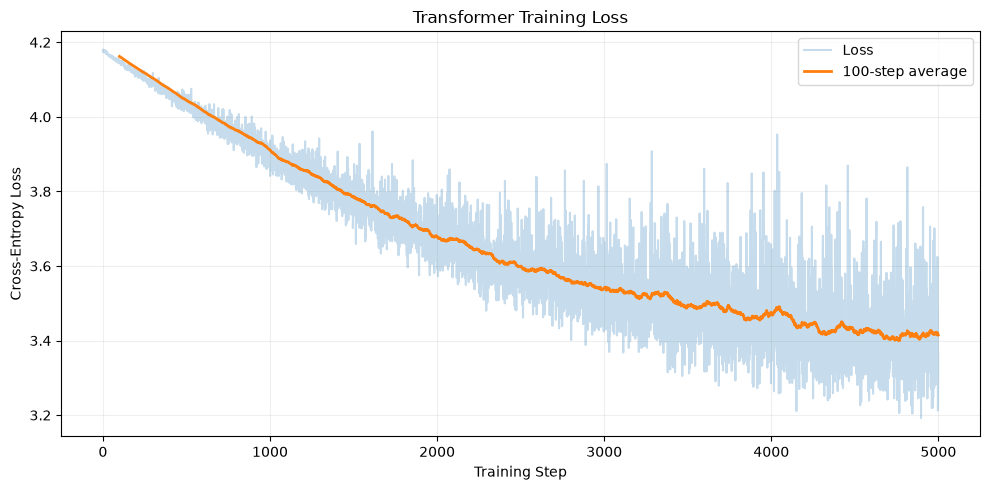

In [14]:
import matplotlib.pyplot as plt

losses_array = np.array(losses)

window = 100

moving_average = np.convolve(losses_array, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 5))
plt.plot(losses_array, alpha=0.25, label="Loss")

plt.plot(range(window - 1, len(losses_array)), moving_average, linewidth=2, label="100-step average")

plt.xlabel("Training Step")
plt.ylabel("Cross-Entropy Loss")
plt.title("Transformer Training Loss")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../images/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()